In [2]:
import pickle
import gc
import numpy as np
import matplotlib.pyplot as plt
from plot_scripts.util import make_plot_dir
from tqdm import tqdm
from model.ratings import get_truth_rankings, get_truth_probability, ranking_to_probability_dist_sparse
from model.user import UserType

run_type = 'epidemic'
runs = []
for a in [0.01, 0.02, 0.05, 0.1, 0.25]:
    for j in [1, 8, 32, 128, 256, 512]:
        runs.append(f'{a}-{j}')

def getText(run_index):
    return f"{int(runs[run_index]*100)}% adversaries"

compute_jaccard = False
jaccard_baseline = 0

by_times = []
totals = np.zeros(len(runs))

average_cache_values = []
#average_leech_ratings = []
#leech_caching_percentage = []
average_divergences = np.zeros(len(runs))
groupings = []
cache_counts = []
mean_jaccards = np.zeros(len(runs))
for run in runs:
    #leech_caching_percentage.append(np.zeros(1000000))
    #average_leech_ratings.append(np.zeros(1000000))
    cache_counts.append(np.zeros(1000000))
    groupings.append([[], [], []])
    average_cache_values.append(np.zeros(6))


satisfaction_grouping_percents = []
satisfaction_grouping_totals = []
for run in runs:
    satisfaction_grouping_percents.append(np.array([0, 0, 0, 0, 0, 0]))
    satisfaction_grouping_totals.append(np.array([0, 0, 0, 0, 0, 0]))

satisfaction_by_good = []
satisfaction_by_bad = []
for run in runs:
    satisfaction_by_good.append(np.array([0, 0, 0, 0, 0, 0]))
    satisfaction_by_bad.append(np.array([0, 0, 0, 0, 0, 0]))
    
include_unsatisfied = False

def binned_sparse_distance(sparse_vec, dense_vec):
    """
    sparse_vec: scipy.sparse.csr_matrix of shape (1, n)
    dense_vec: numpy array of shape (n,)
    Returns: average of L1 distances over 5 bins
    """

    assert sparse_vec.shape[1] == dense_vec.shape[0], "Dimension mismatch"

    data = sparse_vec.data
    indices = sparse_vec.indices

    bins = [
        (0, 9),
        (10, 99),
        (100, 999),
        (1000, 9999),
        (10000, 99999),
        (100000, np.inf),
    ]

    distances = []

    for lower, upper in bins:
        # Identify entries in the current bin
        mask = (data >= lower) & (data <= upper)
        if not np.any(mask):
            distances.append(0.0)
            continue

        bin_indices = indices[mask]
        bin_sparse_vals = data[mask]
        bin_dense_vals = dense_vec[bin_indices]

        # Compute L1 distance on support
        dist = np.sum(bin_sparse_vals - bin_dense_vals)

        # Optionally normalize by number of entries to avoid scale issues
        dist /= len(bin_indices)

        distances.append(dist)

    return distances


make_plot_dir(run_type)

if compute_jaccard:
    print("Opening jaccard baseline")
    with open(f"data/runs/{run_type}/{jaccard_baseline}/users", "rb") as f:
        jaccard_users = pickle.load(f)

for index, run in enumerate(runs):
    print(f"RUN {run}")
    with open(f"data/runs/{run_type}/{run}/config", "rb") as f:
        config = pickle.load(f)
    print("Opening users")
    with open(f"data/runs/{run_type}/{run}/users", "rb") as f:   
        try:
            users = pickle.load(f)
        except Exception as e:
            print(f"Failed to load: {e}")
            continue

    ground_truth_ratings = get_truth_rankings(config.PAGE_COUNT)
    ground_truth_dist = get_truth_probability(config.PAGE_COUNT)

    satisfied_by_time = np.zeros(len(config.POSTBLACKOUT_DAYS) * 48)
    total = 0
    total_leeches = 0
    total_good = 0
    for user_index, user in tqdm(enumerate(users)):
        cache_counts[index][list(user.stored_pages)] += 1
        if user.user_type != UserType.ADVERSARY:
            total_good += 1
        if compute_jaccard and user.user_type != UserType.ADVERSARY and user.stored_pages:
            mean_jaccards[index] += \
                len(jaccard_users[user_index].stored_pages.intersection(user.stored_pages)) / \
                len(jaccard_users[user_index].stored_pages.union(user.stored_pages))
        if user.user_type == UserType.LEECH and user.computed_preferences is not None:
            total_leeches += 1
            '''user.computed_preferences.data[user.computed_preferences.data == 0] = 1
            probabilities = ranking_to_probability_dist_sparse(user.computed_preferences)
            data = probabilities.data
            indices = probabilities.indices
            assert not (data == 0).any(), "There are still explicitly stored zeros in the sparse matrix."
            
            # Compute KL
            kl_terms = data * (np.log(data) - np.log(ground_truth_dist[indices]))
            kl_divergence = kl_terms.sum()
            average_divergences[index] += kl_divergence
            
            average_cache_values[index] += binned_sparse_distance(user.computed_preferences, ground_truth_ratings)'''

            #average_leech_ratings[index] += user.computed_preferences.toarray().flatten()
        '''
        if user.user_type == UserType.LEECH:
            onehot = np.zeros_like(leech_caching_percentage[index])
            onehot[list(user.stored_pages)] = 1
            leech_caching_percentage[index] += onehot'''
            
        total += len(user.requested_pages)
        for request in user.requested_pages:
            if request.is_resolved():
                satisfied_by_time[
                    (request.resolved_days[0] - config.POSTBLACKOUT_DAYS[0]) * 48
                    + request.resolved_timesteps[0]
                ] += 1

            grouping_index = 0
            if request.index >= 100 and request.index <= 9999:
                grouping_index = 1
            elif request.index >= 10000:
                grouping_index = 2
        
            if request.is_resolved():
                groupings[index][grouping_index].append(
                    ((request.resolved_days[0] - request.started_day) * 48
                    + (request.resolved_timesteps[0] - request.started_timestep))/48
                )
            elif include_unsatisfied:
                groupings[index][grouping_index].append(
                    
                    ((config.POSTBLACKOUT_DAYS[-1] - request.started_day) * 48
                    + (48 - request.started_timestep))/48
                )
            grouping_index = 0
            if request.index >= 10 and request.index <= 99:
                grouping_index = 1
            elif request.index >= 100 and request.index <= 999:
                grouping_index = 2
            elif request.index >= 1000 and request.index <= 9999:
                grouping_index = 3
            elif request.index >= 10000 and request.index <= 99999:
                grouping_index = 4
            elif request.index >= 100000:
                grouping_index = 5

            satisfaction_grouping_totals[index][grouping_index] += 1
            if request.is_resolved():
                for who_by in request.resolved_by:
                    if users[who_by].user_type == UserType.ADVERSARY:
                        satisfaction_by_bad[index][grouping_index] += 1
                    else:
                        satisfaction_by_good[index][grouping_index] += 1
                
                satisfaction_grouping_percents[index][grouping_index] += 1
                
    #mean_jaccards[index] /= total_good            
    #average_cache_values[index] /= total_leeches
    #average_divergences[index] /= total_leeches
    #average_leech_ratings[index] /= total_leeches
    #leech_caching_percentage[index] /= total_leeches
    totals[index] = total
    by_times.append(satisfied_by_time)
    users = None
    print("Garbage collection")
    gc.collect()


RUN 0.01-1
Opening users


25000it [00:04, 5346.95it/s]


Garbage collection
RUN 0.01-8
Opening users


25000it [00:04, 5657.99it/s]


Garbage collection
RUN 0.01-32
Opening users


...

Garbage collection
RUN 0.25-256
Opening users


25000it [00:17, 1417.35it/s]


Garbage collection
RUN 0.25-512
Opening users


25000it [00:10, 2333.37it/s]


Garbage collection


### for index, run in enumerate(runs):
    if run != '0.01-60' and run != '0.01-720':
        continue
    print(f"RUN {run}")
    with open(f"data/runs/{run_type}/{run}/config", "rb") as f:
        config = pickle.load(f)
    print("Opening users")
    with open(f"data/runs/{run_type}/{run}/users", "rb") as f:   
        try:
            users = pickle.load(f)
        except Exception as e:
            print(f"Failed to load: {e}")
            continue

    ground_truth_ratings = get_truth_rankings(config.PAGE_COUNT)
    ground_truth_dist = get_truth_probability(config.PAGE_COUNT)

    satisfied_by_time = np.zeros(len(config.POSTBLACKOUT_DAYS) * 48)
    total = 0
    total_leeches = 0
    total_good = 0
    for user_index, user in tqdm(enumerate(users)):
        cache_counts[index][list(user.stored_pages)] += 1
        if user.user_type != UserType.ADVERSARY:
            total_good += 1
        if compute_jaccard and user.user_type != UserType.ADVERSARY and user.stored_pages:
            mean_jaccards[index] += \
                len(jaccard_users[user_index].stored_pages.intersection(user.stored_pages)) / \
                len(jaccard_users[user_index].stored_pages.union(user.stored_pages))
        if user.user_type == UserType.LEECH and user.computed_preferences is not None:
            total_leeches += 1
            '''user.computed_preferences.data[user.computed_preferences.data == 0] = 1
            probabilities = ranking_to_probability_dist_sparse(user.computed_preferences)
            data = probabilities.data
            indices = probabilities.indices
            assert not (data == 0).any(), "There are still explicitly stored zeros in the sparse matrix."
            
            # Compute KL
            kl_terms = data * (np.log(data) - np.log(ground_truth_dist[indices]))
            kl_divergence = kl_terms.sum()
            average_divergences[index] += kl_divergence
            
            average_cache_values[index] += binned_sparse_distance(user.computed_preferences, ground_truth_ratings)'''

            #average_leech_ratings[index] += user.computed_preferences.toarray().flatten()

        '''if user.user_type == UserType.LEECH:
            onehot = np.zeros_like(leech_caching_percentage[index])
            onehot[list(user.stored_pages)] = 1
            leech_caching_percentage[index] += onehot'''
            
        total += len(user.requested_pages)
        for request in user.requested_pages:
            if request.is_resolved():
                satisfied_by_time[
                    (request.resolved_days[0] - config.POSTBLACKOUT_DAYS[0]) * 48
                    + request.resolved_timesteps[0]
                ] += 1

            grouping_index = 0
            if request.index >= 100 and request.index <= 9999:
                grouping_index = 1
            elif request.index >= 10000:
                grouping_index = 2
        
            if request.is_resolved():
                groupings[index][grouping_index].append(
                    ((request.resolved_days[0] - request.started_day) * 48
                    + (request.resolved_timesteps[0] - request.started_timestep))/48
                )
            elif include_unsatisfied:
                groupings[index][grouping_index].append(
                    
                    ((config.POSTBLACKOUT_DAYS[-1] - request.started_day) * 48
                    + (48 - request.started_timestep))/48
                )
            grouping_index = 0
            if request.index >= 10 and request.index <= 99:
                grouping_index = 1
            elif request.index >= 100 and request.index <= 999:
                grouping_index = 2
            elif request.index >= 1000 and request.index <= 9999:
                grouping_index = 3
            elif request.index >= 10000 and request.index <= 99999:
                grouping_index = 4
            elif request.index >= 100000:
                grouping_index = 5

            satisfaction_grouping_totals[index][grouping_index] += 1
            if request.is_resolved():
                for who_by in request.resolved_by:
                    if users[who_by].user_type == UserType.ADVERSARY:
                        satisfaction_by_bad[index][grouping_index] += 1
                    else:
                        satisfaction_by_good[index][grouping_index] += 1
                
                satisfaction_grouping_percents[index][grouping_index] += 1
                
    #mean_jaccards[index] /= total_good            
    #average_cache_values[index] /= total_leeches
    #average_divergences[index] /= total_leeches
    #average_leech_ratings[index] /= total_leeches
    #leech_caching_percentage[index] /= total_leeches
    totals[index] = total
    by_times.append(satisfied_by_time)
    users = None
    print("Garbage collection")
    gc.collect()

In [20]:
print(np.sum(ground_truth_ratings) / 1000000)
for i in range(6):
    intersection = np.minimum(cache_counts[0], cache_counts[i]).sum()
    union = np.maximum(cache_counts[0], cache_counts[i]).sum()
    jaccard = intersection / union if union != 0 else 0

    overlap = np.sum(np.minimum(cache_counts[0], cache_counts[i])) / min(np.sum(cache_counts[0]), np.sum(cache_counts[1]))
    dice = (2 * np.sum(np.minimum(cache_counts[0], cache_counts[i])))/(np.sum(cache_counts[0]) + np.sum(cache_counts[i]))
    print("jaccard:", jaccard)
    print("overlap:", overlap)
    print("dice:", dice)

    average_score = np.sum((cache_counts[i] * ground_truth_ratings)) / np.sum(cache_counts[i])
    print(average_score)

0.6066700465860125
jaccard: 1.0
overlap: 1.009840321825365
dice: 1.0
3.3949255377813228
jaccard: 0.8060337640336482
overlap: 0.8969927317910961
dice: 0.892600991283163
3.214873745441489
jaccard: 0.7308941236186947
overlap: 0.8445905997644992
dice: 0.8445278236783779
3.053708482759302
jaccard: 0.5525950889051472
overlap: 0.7010851079529936
dice: 0.7118341322267405
2.6316988020866052
jaccard: 0.4165886275776881
overlap: 0.5642151834678061
dice: 0.5881575207758636
2.270160799896754
jaccard: 0.3290301236700272
overlap: 0.43702967610080157
dice: 0.495143214303424
2.1203251289407006


hello
1000-0
0.7433209761816735
750-0
0.7385059771587149
500-0
0.73084


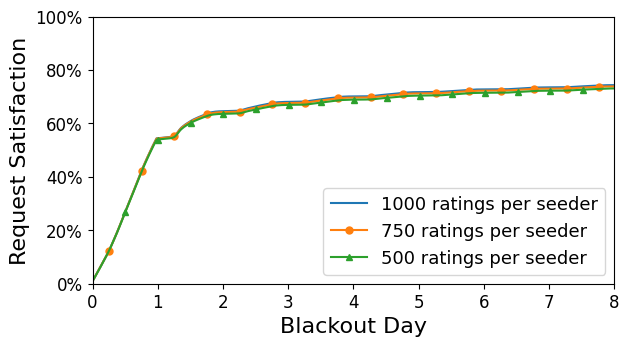

In [116]:
from matplotlib.ticker import PercentFormatter
plt.figure(figsize=(6.18, 3.358), constrained_layout=True)

print("hello")
linestyles = ['solid', 'dotted', 'dashed', 'dashdot']

colors=['red', 'green', 'blue', 'pink']
markers = ['', 'o', '^', 's', 'P', 'D', 'x']
run_subset = [0, 1, 2]
markevery = 24

for index, run_index in enumerate(run_subset):
    plt.plot(
        np.linspace(
            0,
            len(config.POSTBLACKOUT_DAYS),
            len(config.POSTBLACKOUT_DAYS) * 48,
        ),
        np.cumsum(by_times[run_index]) / totals[run_index],
        label=getText(run_index),
        #color = colors[index],
        #linestyle = linestyles[index]
        marker = markers[index],
        markevery = (index * (markevery // (len(run_subset) - 1)), markevery),
        markersize=5
    )
    #print(getText(run_index))
    print(runs[run_index])
    print((np.cumsum(by_times[run_index]) / totals[run_index])[-1])
ax = plt.gca()
#ax.set_xlim([1, 53])
ax.set_xlim([0, 8])
#ax.set_xlim([0, 7])
ax.set_ylim([0, 1])
#ax.set_aspect((9 / 1) / 2)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%

plt.xlabel("Blackout Day", fontsize=16)
plt.ylabel("Request Satisfaction", fontsize=16)
plt.legend(loc='lower right', prop={"size": 13})
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.savefig(f"plots/{run_type}/request-satisfaction-curve.pdf", format="pdf")


0
0 0
0 1
0 2
1
1 0
1 1
1 2
2
2 0
2 1
2 2


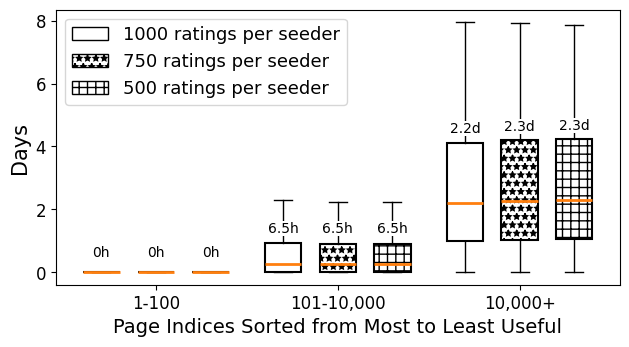

In [121]:
import matplotlib.patches as mpatches

plt.figure(figsize=(6.18, 3.358), constrained_layout=True)

which_runs = [0, 1, 2]
hatch_patterns = ['', '**', '++', 'OO', '//', 'xx']  # 4 distinct, B&W-safe
legend_patches = []
colors=['red', 'green', 'blue', 'pink']

text_offsets = [[0.5, 0.5, 0.5, 0.5, 0.5, 0.5], [1, 1, 1], [2.25, 2.25, 2.25, 2.5]]

for index, run in enumerate(which_runs):
    offset = (-(len(which_runs) // 2 - index) * 0.6)
    bp = plt.boxplot(
        groupings[run],
        positions=[1 + offset, 3 + offset, 5 + offset],
        showfliers=False,
        widths=0.4,
        patch_artist=True,
    )
    # Set consistent black edges and hatch
    for patch in bp['boxes']:
        patch.set(facecolor = 'white', hatch=hatch_patterns[index], edgecolor='black', linewidth=1.5)
    for median in bp['medians']:
        median.set(linewidth=2)
    
    # Create a legend entry
    legend_patches.append(
        mpatches.Patch(facecolor = 'white', hatch=hatch_patterns[index], edgecolor='black',
                       label=getText(run))
    )
    print(run)
    for index2, grouping in enumerate(groupings[run]):
        original_median = np.percentile(np.array(grouping), 50)
        median = original_median
        suffix = 'd'
        if (median < 1):
            median *= 24
            suffix = 'h'
        print(index, index2)
            
        median = round(median, 1)
        if int(median) == median:
            median = int(median)

        plt.text(
            1 + (index2)*2 + offset,
            original_median + text_offsets[index2][index],
            f'{median}{suffix}',
            horizontalalignment='center',
            bbox=dict(facecolor="white", edgecolor="none", pad=0.25)
        )

# Axis labels and formatting
plt.xticks([1, 3, 5], ['1-100', '101-10,000', '10,000+'])
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Days', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="14")

# Add legend with hatches
plt.legend(ncol=1, handles=legend_patches, prop={"size": 13})

extra_string = "unsatisfied" if include_unsatisfied else "satisfied"
plt.savefig(f"plots/{run_type}/box-whisker-{extra_string}.pdf", format="pdf", bbox_inches="tight")
plt.show()

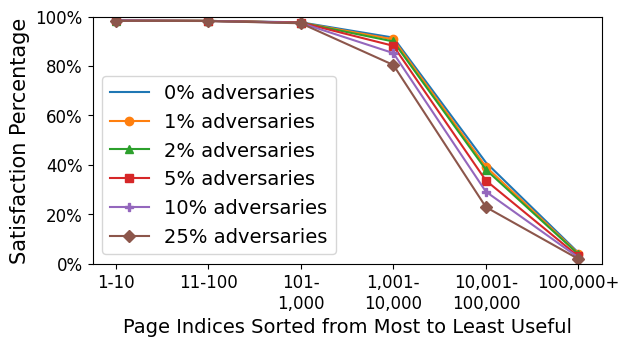

In [61]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(6.18, 3.358), constrained_layout=True)

markers = ['', 'o', '^', 's', 'P', 'D', 'x']
x = [0, 1, 2, 3, 4, 5]
which_runs = [0, 1, 2, 3, 4, 5]
for index, run in enumerate(which_runs):
    plt.plot(x, satisfaction_grouping_percents[run] / satisfaction_grouping_totals[run], marker=markers[index], label=getText(index))

plt.xticks([0, 1, 2, 3, 4, 5], ['1-10', '11-100', '101-\n1,000', '1,001-\n10,000', '10,001-\n100,000', '100,000+'])
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Satisfaction Percentage', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="14")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%
ax = plt.gca()
ax.set_ylim([0, 1])
plt.legend(ncol=1, prop={"size": 14})


'''
offsets = [(0.1, -0.05), (0, -0.05), (0, -0.05), (0, -0.075), (0.1, 0.05), (-0.4, 0)]
rounded_y = np.round(y, 3)
for i in range(6):
    xi = x[i]
    yi = rounded_y[i]
    plt.text(xi + offsets[i][0], yi + offsets[i][1], f"{yi*100}%", ha='center', va='center')
'''
plt.savefig(f"plots/{run_type}/satisfaction-by-index.pdf", format="pdf", bbox_inches="tight")
plt.show()

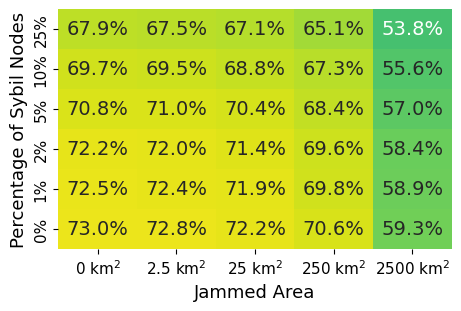

In [13]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(4.5, 3), constrained_layout=True)

# extract unique x and y values in sorted order for axis labels
y_values = sorted(list(set([r.split('-')[0] for r in runs])), key=lambda x: float(x))
x_values = sorted(list(set([r.split('-')[1] for r in runs])), key=lambda x: float(x))

heatmap_data = np.zeros((len(y_values), len(x_values)))

# Fill the heatmap matrix
for run_index, run in enumerate(runs):
    y_str, x_str = run.split('-')
    y_idx = y_values.index(y_str)
    x_idx = x_values.index(x_str)
    metric_value = (np.cumsum(by_times[run_index]) / totals[run_index])[-1]

    heatmap_data[y_idx, x_idx] = metric_value

# Flip the y-axis so that 0 is at the bottom
heatmap_data = np.flipud(heatmap_data)
y_values_flipped = y_values[::-1]
y_values_flipped = [f'{int(float(val)*100)}%' for val in y_values_flipped]

heatmap_data_percent = heatmap_data * 100
percent_labels = np.round(heatmap_data_percent, 1).astype(str) + "%"

# Format as percentage labels
percent_labels = np.round(heatmap_data * 100, 1).astype(str) + "%"

# Plotting
sns.heatmap(
    heatmap_data_percent,
    xticklabels=['0 km$^2$', '2.5 km$^2$', '25 km$^2$', '250 km$^2$', '2500 km$^2$'],
    yticklabels=y_values_flipped,
    annot=percent_labels,
    fmt="",
    cmap="viridis",
    cbar=False,
    annot_kws={'size': 14},
    vmin=3,
    vmax=75
)
plt.xlabel("Jammed Area", fontsize=13)
plt.ylabel("Percentage of Sybil Nodes", fontsize=13)
plt.xticks(rotation=0)
plt.tick_params(axis="both", which="major", labelsize=11)
plt.savefig(f"plots/{run_type}/satisfaction-heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [4]:
print(np.percentile(np.concatenate((groupings[0][0], groupings[0][1], groupings[0][2])), 90))

2.1041666666666665


1.6666666666666667
1.7083333333333333
1.75
2.0
2.8958333333333335
1.5208333333333333
1.5416666666666667
1.6041666666666667
1.8541666666666667
2.8333333333333335
1.3541666666666667
1.375
1.4166666666666667
1.6666666666666667
2.6875
1.2083333333333333
1.2083333333333333
1.2708333333333333
1.4791666666666667
2.5416666666666665
1.1666666666666667
1.1666666666666667
1.2083333333333333
1.4375
2.4375
1.125
1.125
1.179166666666788
1.4166666666666667
2.3958333333333335


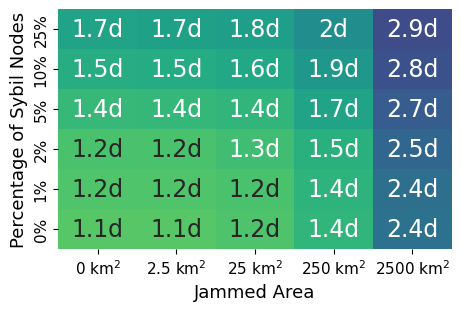

In [14]:
plt.figure(figsize=(4.5, 3), constrained_layout=True)

# extract unique x and y values in sorted order for axis labels
y_values = sorted(list(set([r.split('-')[0] for r in runs])), key=lambda x: float(x))
x_values = sorted(list(set([r.split('-')[1] for r in runs])), key=lambda x: float(x))

heatmap_data = np.zeros((len(y_values), len(x_values)))

# Fill the heatmap matrix
for run_index, run in enumerate(runs):
    y_str, x_str = run.split('-')
    y_idx = y_values.index(y_str)
    x_idx = x_values.index(x_str)
    metric_value = np.percentile(np.concatenate((groupings[run_index][0], groupings[run_index][1])), 90)
    
    heatmap_data[y_idx, x_idx] = metric_value

# Flip the y-axis so that 0 is at the bottom
heatmap_data = np.flipud(heatmap_data)
y_values_flipped = y_values[::-1]
y_values_flipped = [f'{int(float(val)*100)}%' for val in y_values_flipped]

def getlabel(i):
    print(i)
    suffix = 'd'
    if (i < 1):
        i *= 24
        suffix = 'h'
        
    i = round(i, 1)
    if int(i) == i:
        i = int(i)
    return f'{i}{suffix}'

annot_array = [[getlabel(val) for val in row] for row in heatmap_data]

# Plotting
sns.heatmap(
    heatmap_data,
    xticklabels=['0 km$^2$', '2.5 km$^2$', '25 km$^2$', '250 km$^2$', '2500 km$^2$'],
    yticklabels=y_values_flipped,
    annot=annot_array,
    fmt="",
    cmap="viridis_r",
    cbar=False,
    vmin=0.2,
    vmax=3.7,
    annot_kws={'size': 17}
)
plt.xlabel("Jammed Area", fontsize=13)
plt.ylabel("Percentage of Sybil Nodes", fontsize=13)
plt.xticks(rotation=0)
plt.tick_params(axis="both", which="major", labelsize=11)
plt.savefig(f"plots/{run_type}/latency-heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
for run in runs:
    with open(f"data/runs/stalking/{run}/config", "rb") as f:
        config = pickle.load(f)
        print(config.TOTAL_USERS)
        print(config.STALKING)
        print(config.POW_LIMIT)
        print("adversary", config.NUM_ADVERSARY)
        print("leech", config.NUM_LEECH)
        print("seeder", config.NUM_REGULAR)

[0 0 0 0 0 0]
[594181 459369 465585 323243  59187   4042]
[60008 46365 47047 43659 19761  2149]
[ 1976  1528  7861 46505 78167 83122]
[581121 452489 445852 288865  52175   3703]
[58949 45800 45878 43872 32669 26181]
[  3805   3208  15968  85463 144407 152622]
[573651 449638 437855 262927  43470   2927]
[58356 45642 45912 44201 35910 31885]
[  9730   8217  44514 180031 266732 280379]
[551640 429953 392298 185686  25731   1665]
[56711 44180 44313 42944 38836 37287]
[ 19182  16742  89786 264644 339170 351544]
[518465 397241 324407 114977  13139    889]
[54311 41775 42052 41328 39252 39245]
[ 46028  43636 155283 296810 332513 339993]
[397765 298962 192506  43410   3922    264]
[44846 34534 35126 34741 34348 34687]


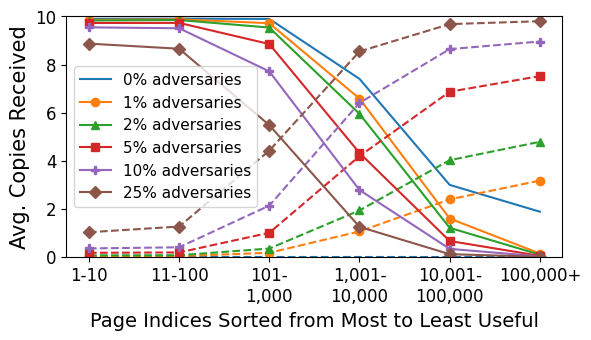

In [13]:
from matplotlib.ticker import PercentFormatter
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']
markers = ['', 'o', '^', 's', 'P', 'D', 'x']
plt.tight_layout()
x = [0, 1, 2, 3, 4, 5]
which_runs = [0, 1, 2, 3, 4, 5]
for index, run in enumerate(which_runs):
    plt.plot(
        x,
        satisfaction_by_good[run] / satisfaction_grouping_percents[run],
        marker=markers[index],
        label = f"{int(runs[run]*100)}% adversaries",
        color=colors[index]
    )
    plt.plot(
        x,
        satisfaction_by_bad[run] / satisfaction_grouping_percents[run],
        marker=markers[index],
        linestyle='--',
        color = colors[index]
    )
    print(satisfaction_by_bad[run])
    print(satisfaction_by_good[run])
    print(satisfaction_grouping_percents[run])

plt.xticks([0, 1, 2, 3, 4, 5], ['1-10', '11-100', '101-\n1,000', '1,001-\n10,000', '10,001-\n100,000', '100,000+'])
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Avg. Copies Received', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="14")

ax = plt.gca()
ax.set_ylim([0, 10])
plt.gca().set_aspect((6 / 10) / 2.25)

plt.legend(ncol=1, prop={"size": 11})


'''
offsets = [(0.1, -0.05), (0, -0.05), (0, -0.05), (0, -0.075), (0.1, 0.05), (-0.4, 0)]
rounded_y = np.round(y, 3)
for i in range(6):
    xi = x[i]
    yi = rounded_y[i]
    plt.text(xi + offsets[i][0], yi + offsets[i][1], f"{yi*100}%", ha='center', va='center')
'''
plt.savefig(f"plots/{run_type}/avg-copies-received.pdf", format="pdf", bbox_inches="tight")
plt.show()

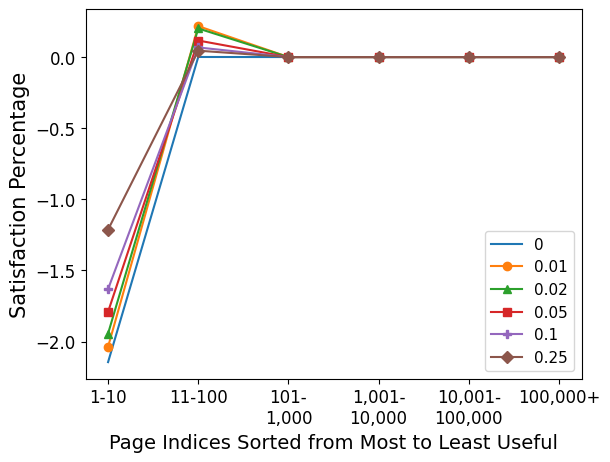

In [19]:
from matplotlib.ticker import PercentFormatter

markers = ['', 'o', '^', 's', 'P', 'D', 'x']
plt.tight_layout()
x = [0, 1, 2, 3, 4, 5]
which_runs = [0, 1, 2, 3, 4, 5]
for index, run in enumerate(which_runs):
    plt.plot(x, average_cache_values[run], marker=markers[index], label=getText(run))

plt.xticks([0, 1, 2, 3, 4, 5], ['1-10', '11-100', '101-\n1,000', '1,001-\n10,000', '10,001-\n100,000', '100,000+'])
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Satisfaction Percentage', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="14")
#plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%

ax = plt.gca()
#ax.set_ylim([0, 1])
#plt.gca().set_aspect((6 / 1) / 2.25)

plt.legend(ncol=1, prop={"size": 11})


'''
offsets = [(0.1, -0.05), (0, -0.05), (0, -0.05), (0, -0.075), (0.1, 0.05), (-0.4, 0)]
rounded_y = np.round(y, 3)
for i in range(6):
    xi = x[i]
    yi = rounded_y[i]
    plt.text(xi + offsets[i][0], yi + offsets[i][1], f"{yi*100}%", ha='center', va='center')
'''
plt.savefig(f"plots/{run_type}/satisfaction-by-index.pdf", format="pdf", bbox_inches="tight")
plt.show()

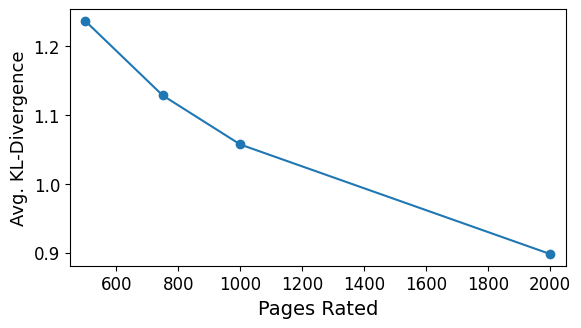

In [8]:
from matplotlib.ticker import PercentFormatter

markers = ['', 'o', '^', 's', 'P', 'D', 'x']
plt.tight_layout()
x = [int(run.split('-')[0]) for run in runs]
plt.plot(x, average_divergences, marker='o')

plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Avg. KL-Divergence', fontsize="13")
plt.xlabel("Pages Rated", fontsize="14")
#plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%

ax = plt.gca()
ax.set_xlim([450, 2050])
#ax.set_ylim([0, 1])
plt.gca().set_aspect(1500 / 0.3 / 2.25)


'''
offsets = [(0.1, -0.05), (0, -0.05), (0, -0.05), (0, -0.075), (0.1, 0.05), (-0.4, 0)]
rounded_y = np.round(y, 3)
for i in range(6):
    xi = x[i]
    yi = rounded_y[i]
    plt.text(xi + offsets[i][0], yi + offsets[i][1], f"{yi*100}%", ha='center', va='center')
'''
plt.savefig(f"plots/{run_type}/kl-divergence.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [5]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(5, 5), constrained_layout=True)

# extract unique x and y values in sorted order for axis labels
y_values = sorted(list(set([r.split('-')[0][1:] for r in runs])), key=lambda x: float(x))
x_values = sorted(list(set([r.split('-')[1][1:] for r in runs])), key=lambda x: float(x))

heatmap_data = np.zeros((len(y_values), len(x_values)))

# Fill the heatmap matrix
for run_index, run in enumerate(runs):
    y_str, x_str = run.split('-')
    y_idx = y_values.index(y_str[1:])
    x_idx = x_values.index(x_str[1:])
    metric_value = (np.cumsum(by_times[run_index]) / totals[run_index])[-1]

    heatmap_data[y_idx, x_idx] = metric_value

# Flip the y-axis so that 0 is at the bottom
heatmap_data = np.flipud(heatmap_data)
y_values_flipped = y_values[::-1]
y_values_flipped = [f'{int(float(val)*100)}%' for val in y_values_flipped]

heatmap_data_percent = heatmap_data * 100
percent_labels = np.round(heatmap_data_percent, 1).astype(str) + "%"

# Format as percentage labels
percent_labels = np.round(heatmap_data * 100, 1).astype(str) + "%"

# Plotting
sns.heatmap(
    heatmap_data_percent,
    xticklabels=['0 cells', '10 cells', '50 cells', '100 cells', '300 cells'],
    yticklabels=y_values_flipped,
    annot=percent_labels,
    fmt="",
    cmap="viridis",
    cbar=False,
    vmin=3,
    vmax=75,
    annot_kws={'size': 14}
)
plt.xlabel("Jammed Area", fontsize=13)
plt.ylabel("Percentage of Sybil Nodes", fontsize=13)
plt.xticks(rotation=0)
plt.savefig(f"plots/{run_type}/satisfaction-heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

['0.01-1', '0.01-8', '0.01-32', '0.01-128', '0.01-256', '0.01-512', '0.02-1', '0.02-8', '0.02-32', '0.02-128', '0.02-256', '0.02-512', '0.05-1', '0.05-8', '0.05-32', '0.05-128', '0.05-256', '0.05-512', '0.1-1', '0.1-8', '0.1-32', '0.1-128', '0.1-256', '0.1-512', '0.25-1', '0.25-8', '0.25-32', '0.25-128', '0.25-256', '0.25-512']


ValueError: '.01' is not in list

<Figure size 450x300 with 0 Axes>

0.4645833333333371
0.4791666666666667
0.5625
0.5416666666666666
1.0479166666666706
0.4791666666666667
0.4166666666666667
0.4583333333333333
0.5208333333333334
0.9166666666666666
0.34375
0.375
0.4166666666666667
0.4166666666666667
0.6666666666666666
0.2916666666666667
0.25
0.2916666666666667
0.3125
0.5208333333333334
0.22916666666666666
0.20833333333333334
0.25
0.3125
0.5416666666666666
0.22916666666666666
0.20833333333333334
0.22916666666666666
0.25
0.4583333333333333


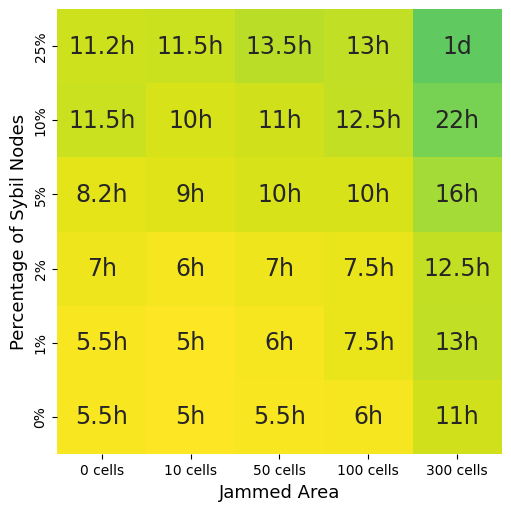

In [127]:
plt.figure(figsize=(5, 5), constrained_layout=True)

# extract unique x and y values in sorted order for axis labels
y_values = sorted(list(set([r.split('-')[0][1:] for r in runs])), key=lambda x: float(x))
x_values = sorted(list(set([r.split('-')[1][1:] for r in runs])), key=lambda x: float(x))

heatmap_data = np.zeros((len(y_values), len(x_values)))

# Fill the heatmap matrix
for run_index, run in enumerate(runs):
    y_str, x_str = run.split('-')
    y_idx = y_values.index(y_str[1:])
    x_idx = x_values.index(x_str[1:])
    metric_value = np.percentile(np.concatenate((groupings[run_index][0], groupings[run_index][1])), 90)
    
    heatmap_data[y_idx, x_idx] = metric_value

# Flip the y-axis so that 0 is at the bottom
heatmap_data = np.flipud(heatmap_data)
y_values_flipped = y_values[::-1]
y_values_flipped = [f'{int(float(val)*100)}%' for val in y_values_flipped]

def getlabel(i):
    print(i)
    suffix = 'd'
    if (i < 1):
        i *= 24
        suffix = 'h'
        
    i = round(i, 1)
    if int(i) == i:
        i = int(i)
    return f'{i}{suffix}'

annot_array = [[getlabel(val) for val in row] for row in heatmap_data]

# Plotting
sns.heatmap(
    heatmap_data,
    xticklabels=['0 cells', '10 cells', '50 cells', '100 cells', '300 cells'],
    yticklabels=y_values_flipped,
    annot=annot_array,
    fmt="",
    cmap="viridis_r",
    cbar=False,
    vmin=0.2,
    vmax=3.7,
    annot_kws={'size': 17}
)
plt.xlabel("Jammed Area", fontsize=13)
plt.ylabel("Percentage of Sybil Nodes", fontsize=13)
plt.xticks(rotation=0)
plt.savefig(f"plots/{run_type}/latency-heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

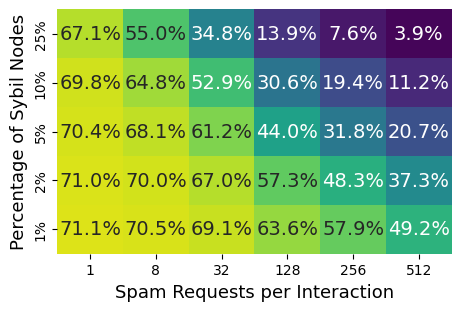

In [9]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(4.5, 3), constrained_layout=True)


# extract unique x and y values in sorted order for axis labels
y_values = sorted(list(set([r.split('-')[0] for r in runs])), key=lambda x: float(x))
x_values = sorted(list(set([r.split('-')[1] for r in runs])), key=lambda x: float(x))

heatmap_data = np.zeros((len(y_values), len(x_values)))

# Fill the heatmap matrix
for run_index, run in enumerate(runs):
    y_str, x_str = run.split('-')
    y_idx = y_values.index(y_str)
    x_idx = x_values.index(x_str)
    metric_value = (np.cumsum(by_times[run_index]) / totals[run_index])[-1]

    heatmap_data[y_idx, x_idx] = metric_value

# Flip the y-axis so that 0 is at the bottom
heatmap_data = np.flipud(heatmap_data)
y_values_flipped = y_values[::-1]
y_values_flipped = [f'{int(float(val)*100)}%' for val in y_values_flipped]

heatmap_data_percent = heatmap_data * 100
percent_labels = np.round(heatmap_data_percent, 1).astype(str) + "%"

# Format as percentage labels
percent_labels = np.round(heatmap_data * 100, 1).astype(str) + "%"

# Plotting
sns.heatmap(
    heatmap_data_percent,
    xticklabels=['1', '8', '32', '128', '256', '512'],
    yticklabels=y_values_flipped,
    annot=percent_labels,
    fmt="",
    cmap="viridis",
    cbar=False,
    annot_kws={'size': 14},
    vmin=3,
    vmax=75
)
plt.xlabel("Spam Requests per Interaction", fontsize=13)
plt.ylabel("Percentage of Sybil Nodes", fontsize=13)
plt.xticks(rotation=0)
plt.savefig(f"plots/{run_type}/satisfaction-heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

3.625
3.6875
3.6875
3.5625
3.3958333333333335
3.4166666666666665
3.375
3.375
3.4375
3.4375
3.3958333333333335
3.3958333333333335
3.2708333333333335
3.2708333333333335
3.3125
3.375
3.375
3.375
3.1875
3.2291666666666665
3.25
3.25
3.3125
3.3125
3.1875
3.1875
3.1875
3.2291666666666665
3.25
3.25


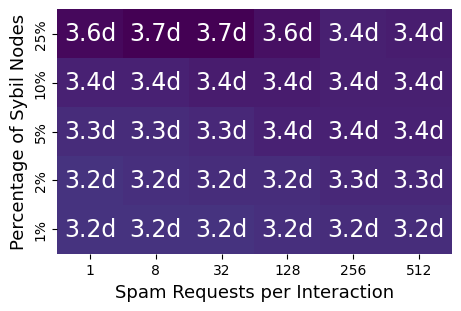

In [11]:
plt.figure(figsize=(4.5, 3), constrained_layout=True)
# extract unique x and y values in sorted order for axis labels
y_values = sorted(list(set([r.split('-')[0] for r in runs])), key=lambda x: float(x))
x_values = sorted(list(set([r.split('-')[1] for r in runs])), key=lambda x: float(x))

heatmap_data = np.zeros((len(y_values), len(x_values)))

# Fill the heatmap matrix
for run_index, run in enumerate(runs):
    y_str, x_str = run.split('-')
    y_idx = y_values.index(y_str)
    x_idx = x_values.index(x_str)
    metric_value = np.percentile(np.concatenate((groupings[run_index][0], groupings[run_index][1])), 90)
    
    heatmap_data[y_idx, x_idx] = metric_value

# Flip the y-axis so that 0 is at the bottom
heatmap_data = np.flipud(heatmap_data)
y_values_flipped = y_values[::-1]
y_values_flipped = [f'{int(float(val)*100)}%' for val in y_values_flipped]

def getlabel(i):
    print(i)
    suffix = 'd'
    if (i < 1):
        i *= 24
        suffix = 'h'
        
    i = round(i, 1)
    if int(i) == i:
        i = int(i)
    return f'{i}{suffix}'

annot_array = [[getlabel(val) for val in row] for row in heatmap_data]

# Plotting
sns.heatmap(
    heatmap_data,
    xticklabels=['1', '8', '32', '128', '256', '512'],
    yticklabels=y_values_flipped,
    annot=annot_array,
    fmt="",
    cmap="viridis_r",
    cbar=False,
    annot_kws={'size': 17},
    vmin=0.2,
    vmax=3.7,
)
plt.xlabel("Spam Requests per Interaction", fontsize=13)
plt.ylabel("Percentage of Sybil Nodes", fontsize=13)
plt.xticks(rotation=0)
plt.savefig(f"plots/{run_type}/latency-heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [1]:
from brokenaxes import brokenaxes
plt.figure(figsize=(6.18, 3.358))
plt.savefig(f"plots/{run_type}/cache-values.pdf", format="pdf")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

bax = brokenaxes(xlims=((0, 500), (10**6 - 550, 10**6)), wspace=0.1)

markers = ['', 'o', '^', 's', 'P', 'D', 'x']


markevery = 50
for i, rating in enumerate(average_leech_ratings):
    bax.plot(
        np.arange(500),
        rating[:500],
        colors[i],
        marker=markers[i],
        markevery = (i * (markevery // (len(average_leech_ratings) - 1)), markevery),
        markersize=4,
        label = getText(i)
    )
    bax.plot(
        np.arange(10**6 - 550, 10**6),
        rating[10**6 - 550:],
        colors[i],
        marker=markers[i],
        markevery = (i * (markevery // (len(average_leech_ratings) - 1)), markevery),
        markersize=4
    )

bax.legend(ncol = 2, loc='upper right', prop={"size": 12})
bax.set_xlabel("Page Indices Sorted from Most to Least Useful", labelpad=40, fontsize=14)
bax.set_ylabel("Avg. Leecher Rating", fontsize=14)
for ax in bax.axs:
    ax.tick_params(axis='both', labelsize=13)

plt.savefig(f"plots/{run_type}/cache-values.pdf", format="pdf", bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

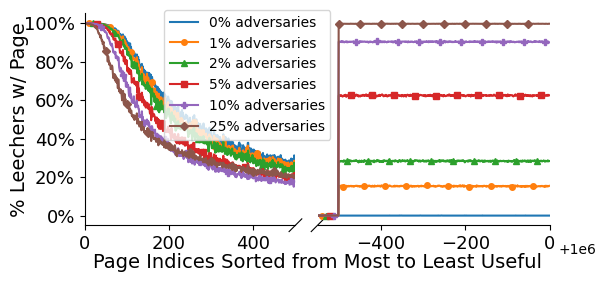

In [17]:
from matplotlib.ticker import PercentFormatter
from brokenaxes import brokenaxes
plt.figure(figsize=(6, 2.75))
plt.savefig(f"plots/{run_type}/cache-values.pdf", format="pdf")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

bax = brokenaxes(xlims=((0, 500), (10**6 - 550, 10**6)), wspace=0.1)

markers = ['', 'o', '^', 's', 'P', 'D', 'x']


markevery = 50
for i, rating in enumerate(leech_caching_percentage):
    bax.plot(
        np.arange(500),
        rating[:500],
        colors[i],
        marker=markers[i],
        markevery = (i * (markevery // (len(leech_caching_percentage) - 1)), markevery),
        markersize=4,
        label = getText(i)
    )
    bax.plot(
        np.arange(10**6 - 550, 10**6),
        rating[10**6 - 550:],
        colors[i],
        marker=markers[i],
        markevery = (i * (markevery // (len(leech_caching_percentage) - 1)), markevery),
        markersize=4
    )

bax.legend(loc='upper center', bbox_to_anchor=(0.35, 1.05))
bax.set_xlabel("Page Indices Sorted from Most to Least Useful", labelpad=20, fontsize=14)
bax.set_ylabel("% Leechers w/ Page", fontsize=14, labelpad=40)
for ax in bax.axs:
    ax.tick_params(axis='both', labelsize=13)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%

# Access the right-hand axis (second x-axis in brokenaxes)
right_ax = bax.axs[1]  # axs is a list of the underlying subplots

# Move the offset text to the right side
offset_text = right_ax.xaxis.get_offset_text()
offset_text.set_horizontalalignment('right')
offset_text.set_verticalalignment('bottom')
offset_text.set_x(1.2)            # move to right edge in axis coordinates
offset_text.set_y(200)

plt.savefig(f"plots/{run_type}/percent-cached-by.pdf", format="pdf", bbox_inches='tight')
plt.show()

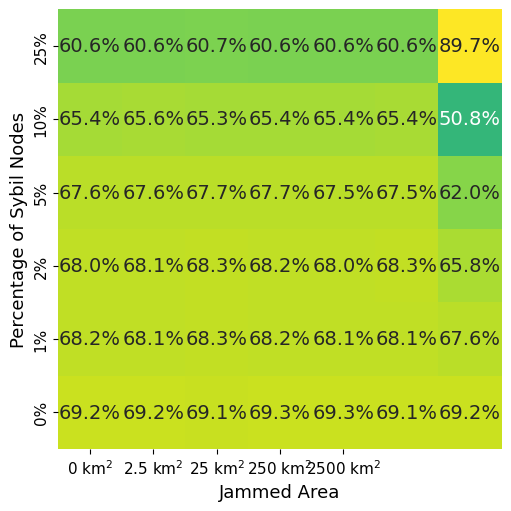

In [6]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(5, 5), constrained_layout=True)

# extract unique x and y values in sorted order for axis labels
y_values = sorted(list(set([r.split('-')[0] for r in runs])), key=lambda x: float(x))
x_values = sorted(list(set([r.split('-')[1] for r in runs])), key=lambda x: float(x))

heatmap_data = np.zeros((len(y_values), len(x_values)))

# Fill the heatmap matrix
for run_index, run in enumerate(runs):
    y_str, x_str = run.split('-')
    y_idx = y_values.index(y_str)
    x_idx = x_values.index(x_str)
    metric_value = (np.cumsum(by_times[run_index]) / totals[run_index])[-1]

    heatmap_data[y_idx, x_idx] = metric_value

# Flip the y-axis so that 0 is at the bottom
heatmap_data = np.flipud(heatmap_data)
y_values_flipped = y_values[::-1]
y_values_flipped = [f'{int(float(val)*100)}%' for val in y_values_flipped]

heatmap_data_percent = heatmap_data * 100
percent_labels = np.round(heatmap_data_percent, 1).astype(str) + "%"

# Format as percentage labels
percent_labels = np.round(heatmap_data * 100, 1).astype(str) + "%"

# Plotting
sns.heatmap(
    heatmap_data_percent,
    xticklabels=['0 km$^2$', '2.5 km$^2$', '25 km$^2$', '250 km$^2$', '2500 km$^2$'],
    yticklabels=y_values_flipped,
    annot=percent_labels,
    fmt="",
    cmap="viridis",
    cbar=False,
    annot_kws={'size': 14},
    vmin=3,
    vmax=75
)
plt.xlabel("Jammed Area", fontsize=13)
plt.ylabel("Percentage of Sybil Nodes", fontsize=13)
plt.xticks(rotation=0)
plt.tick_params(axis="both", which="major", labelsize=11)
plt.savefig(f"plots/{run_type}/satisfaction-heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

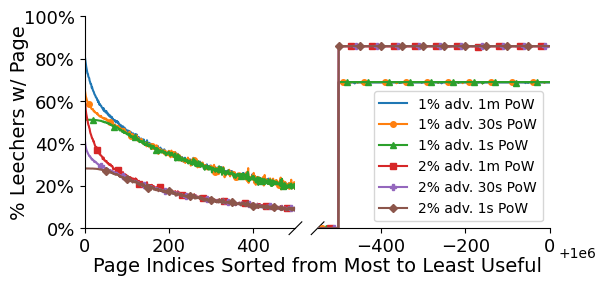

In [28]:
from matplotlib.ticker import PercentFormatter
from brokenaxes import brokenaxes
plt.figure(figsize=(6, 2.75))
plt.savefig(f"plots/{run_type}/cache-values.pdf", format="pdf")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

bax = brokenaxes(xlims=((0, 500), (10**6 - 550, 10**6)), wspace=0.1)

markers = ['', 'o', '^', 's', 'P', 'D', 'x', '|']

markevery = 50
color_i = 0
run_choices = ['0.01-30', '0.01-60', '0.01-1800', '0.02-30', '0.02-60', '0.02-1800']
for i, rating in enumerate(leech_caching_percentage):
    if runs[i] not in run_choices:
        continue
    parts = runs[i].split('-')
    percent = int(float(parts[0])*100)
    timing = '1m' if parts[1] == '30' else f'{1800//int(parts[1])}s'
    bax.plot(
        np.arange(500),
        rating[:500],
        colors[color_i],
        marker=markers[color_i],
        markevery = (i * (markevery // (len(leech_caching_percentage) - 1)), markevery),
        markersize=4,
        label = f'{percent}% adv. {timing} PoW'
    )
    bax.plot(
        np.arange(10**6 - 550, 10**6),
        rating[10**6 - 550:],
        colors[color_i],
        marker=markers[color_i],
        markevery = (i * (markevery // (len(leech_caching_percentage) - 1)), markevery),
        markersize=4
    )
    color_i += 1

bax.legend(loc='lower right', prop={"size": 10})
bax.set_xlabel("Page Indices Sorted from Most to Least Useful", labelpad=20, fontsize=14)
bax.set_ylabel("% Leechers w/ Page", fontsize=14, labelpad=40)
for ax in bax.axs:
    ax.tick_params(axis='both', labelsize=13)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%
    ax.set_ylim([0, 1])

# Access the right-hand axis (second x-axis in brokenaxes)
right_ax = bax.axs[1]  # axs is a list of the underlying subplots

# Move the offset text to the right side
offset_text = right_ax.xaxis.get_offset_text()
offset_text.set_horizontalalignment('right')
offset_text.set_verticalalignment('bottom')
offset_text.set_x(1.2)            # move to right edge in axis coordinates
offset_text.set_y(200)

plt.savefig(f"plots/{run_type}/percent-cached-by.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [30]:
for run in runs:
    if run != '0.25-1800':
        continue
    with open(f"data/runs/stalking/{run}/config", "rb") as f:
        config = pickle.load(f)
        print(config.TOTAL_USERS)
        print(config.STALKING)
        print(config.POW_LIMIT)
        print("adversary", config.NUM_ADVERSARY)
        print("leech", config.NUM_LEECH)
        print("seeder", config.NUM_REGULAR)

25000
True
1800
adversary 6250
leech 14062
seeder 4688


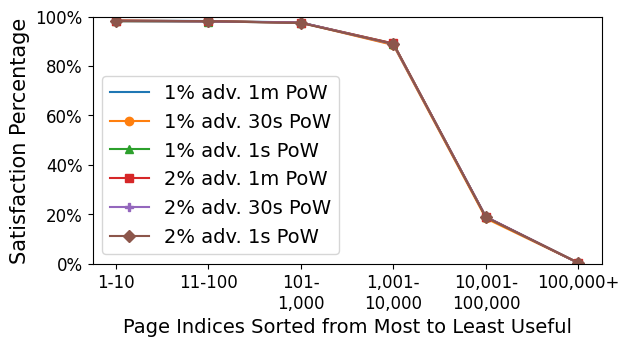

In [81]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(6.18, 3.358), constrained_layout=True)

markers = ['', 'o', '^', 's', 'P', 'D', 'x']
x = [0, 1, 2, 3, 4, 5]
i = 0
run_choices = ['0.01-30', '0.01-60', '0.01-1800', '0.02-30', '0.02-60', '0.02-1800']
for index, rating in enumerate(leech_caching_percentage):
    if runs[index] not in run_choices:
        continue
    parts = runs[index].split('-')
    percent = int(float(parts[0])*100)
    timing = '1m' if parts[1] == '30' else f'{1800//int(parts[1])}s'
    plt.plot(
        x,
        satisfaction_grouping_percents[index] / satisfaction_grouping_totals[index],
        marker=markers[i],
        label=f'{percent}% adv. {timing} PoW'
    )
    i += 1

plt.xticks([0, 1, 2, 3, 4, 5], ['1-10', '11-100', '101-\n1,000', '1,001-\n10,000', '10,001-\n100,000', '100,000+'])
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Satisfaction Percentage', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="14")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%
ax = plt.gca()
ax.set_ylim([0, 1])
plt.legend(ncol=1, prop={"size": 14})


'''
offsets = [(0.1, -0.05), (0, -0.05), (0, -0.05), (0, -0.075), (0.1, 0.05), (-0.4, 0)]
rounded_y = np.round(y, 3)
for i in range(6):
    xi = x[i]
    yi = rounded_y[i]
    plt.text(xi + offsets[i][0], yi + offsets[i][1], f"{yi*100}%", ha='center', va='center')
'''
plt.savefig(f"plots/{run_type}/satisfaction-by-index.pdf", format="pdf", bbox_inches="tight")
plt.show()

0.01-30
0 0
0 1
0.01-60
1 0
1 1
0.01-1800
2 0
2 1
0.02-30
3 0
3 1
0.02-60
4 0
4 1
0.02-1800
5 0
5 1


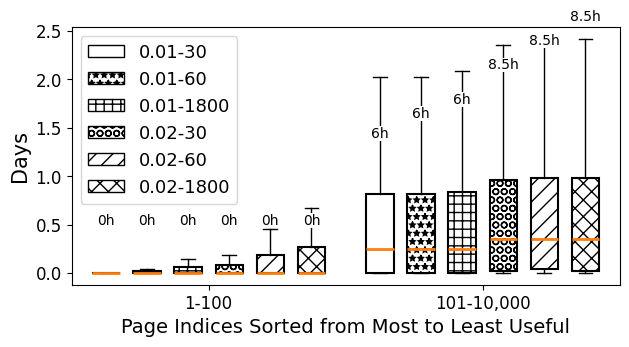

In [80]:
import matplotlib.patches as mpatches

plt.figure(figsize=(6.18, 3.358), constrained_layout=True)

which_runs = [0, 1, 2, 3, 4, 5]
hatch_patterns = ['', '**', '++', 'OO', '//', 'xx']  # 4 distinct, B&W-safe
legend_patches = []
colors=['red', 'green', 'blue', 'pink']

text_offsets = [[0.5, 0.5, 0.5, 0.5, 0.5, 0.5], [1.15, 1.35, 1.5, 1.75, 2, 2.25], [2.5, 2.85, 3.25, 3.5, 3.75, 4.25]]

run_choices = ['0.01-30', '0.01-60', '0.01-1800', '0.02-30', '0.02-60', '0.02-1800']

index = 0
for i, run in enumerate(runs):
    if run not in run_choices:
        continue
    offset = (-(len(which_runs) // 2 - index - 1/2) * 0.6)
    bp = plt.boxplot(
        groupings[i][:2],
        positions=[1 + offset, 5 + offset],
        showfliers=False,
        widths=0.4,
        patch_artist=True,
    )
    # Set consistent black edges and hatch
    for patch in bp['boxes']:
        patch.set(facecolor = 'white', hatch=hatch_patterns[index], edgecolor='black', linewidth=1.5)
    for median in bp['medians']:
        median.set(linewidth=2)
    
    # Create a legend entry
    legend_patches.append(
        mpatches.Patch(facecolor = 'white', hatch=hatch_patterns[index], edgecolor='black',
                       label=run)
    )
    print(run)
    for index2, grouping in enumerate(groupings[i][:2]):
        original_median = np.percentile(np.array(grouping), 50)
        median = original_median
        suffix = 'd'
        if (median < 1):
            median *= 24
            suffix = 'h'
        print(index, index2)
            
        median = round(median, 1)
        if int(median) == median:
            median = int(median)

        plt.text(
            1 + (index2)*4 + offset,
            original_median + text_offsets[index2][index],
            f'{median}{suffix}',
            horizontalalignment='center',
            bbox=dict(facecolor="white", edgecolor="none", pad=0.25)
        )
    index += 1

# Axis labels and formatting
plt.xticks([1, 5], ['1-100', '101-10,000'])
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Days', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="14")

# Add legend with hatches
plt.legend(ncol=1, handles=legend_patches, prop={"size": 13})

extra_string = "unsatisfied" if include_unsatisfied else "satisfied"
plt.savefig(f"plots/{run_type}/box-whisker-{extra_string}.pdf", format="pdf", bbox_inches="tight")
plt.show()